In [1]:
import numpy as np  
import matplotlib.pyplot as plt  
import pandas as pd
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')
import os, yaml
%pip install scikit-learn

Here we'll convert our dataset to the suitable format for pretrained-ViT model

In [2]:
if False:
    import pandas as pd

    xlsx_path = r"C:\Users\Lenovo\OneDrive - Hanoi University of Science and Technology\Desktop\HUST\classes.xlsx"
    csv_path  = r"C:\Users\Lenovo\OneDrive - Hanoi University of Science and Technology\Desktop\HUST\classes.csv"

    # Read xlsx
    df = pd.read_excel(xlsx_path)

    # Remove unnamed columns if any
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # Save to csv
    df.to_csv(csv_path, index=False, sep=";")

    print("Converted xlsx to csv")
    print("Rows", len(df))
    print("Columns", list(df.columns))

**Step1:** Data preparation:
Our data: 7714 samples
Train-test: 5713 samples
Validation: 2001 samples

In [3]:
import os
import re
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# paths
csv_path = r"C:\Users\Lenovo\OneDrive - Hanoi University of Science and Technology\Desktop\HUST\classes.csv"
train_img_dir = r"C:\Users\Lenovo\OneDrive - Hanoi University of Science and Technology\Desktop\HUST\Train-test"
val_img_dir = r"C:\Users\Lenovo\OneDrive - Hanoi University of Science and Technology\Desktop\HUST\valida"

# read csv
df = pd.read_csv(csv_path, sep=';')
df = df.loc[:, ~df.columns.str.contains("Unnamed")]

# collect names
train_names = pd.concat([df["Train–test"], df["Train–test.1"]]).dropna().tolist()
val_names = df["Validation"].dropna().tolist()

# regex to extract core id
pattern = re.compile(r"(.+)-(\d+)-Ag-(\d+)_([A-D])")

def parse_csv_name(name):
    m = pattern.match(name)
    if not m:
        return None
    brand, num, idx, label = m.groups()
    key = f"{brand}-{int(num)}-Ag-{int(idx)}"
    return key, label

def parse_img_name(name):
    name = os.path.splitext(name)[0]
    name = name.replace("-Ori", "")
    parts = name.split("-")
    key = f"{parts[0]}-{int(parts[1])}-Ag-{int(parts[-1])}"
    return key

# index images
train_img_map = {}
for f in os.listdir(train_img_dir):
    if f.endswith(".tif"):
        train_img_map[parse_img_name(f)] = os.path.join(train_img_dir, f)

val_img_map = {}
for f in os.listdir(val_img_dir):
    if f.endswith(".tif"):
        val_img_map[parse_img_name(f)] = os.path.join(val_img_dir, f)

# match train
train_rows = []
train_labels = []

for name in train_names:
    parsed = parse_csv_name(name)
    if not parsed:
        continue
    key, label = parsed
    if key in train_img_map:
        train_rows.append(train_img_map[key])
        train_labels.append(label)

# match validation
val_rows = []
val_labels = []

for name in val_names:
    parsed = parse_csv_name(name)
    if not parsed:
        continue
    key, label = parsed
    if key in val_img_map:
        val_rows.append(val_img_map[key])
        val_labels.append(label)

# encode labels
le = LabelEncoder()
le.fit(train_labels + val_labels)

train_labels_enc = le.transform(train_labels)
val_labels_enc = le.transform(val_labels)

# create dataframes
train_df = pd.DataFrame({
    "file_path": train_rows,
    "label": train_labels_enc
})

val_df = pd.DataFrame({
    "file_path": val_rows,
    "label": val_labels_enc
})

# save
train_df.to_csv("train_data.csv", index=False)
val_df.to_csv("val_data.csv", index=False)

# report
print("Classes")
for i, c in enumerate(le.classes_):
    print(i, c)

print("Train rows", len(train_df))
print("Val rows", len(val_df))


Classes
0 A
1 B
2 C
3 D
Train rows 5713
Val rows 2001


In [4]:
df.describe()
print(df.describe())    
df.info()
print(df.columns)

                Train–test      Train–test.1     Validation
count                 3117              2596           2001
unique                3117              2596           2001
top     Pryntex-61-Ag-69_D  Botlek-62-Ag-9_B  990-09-Ag-9_B
freq                     1                 1              1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3117 entries, 0 to 3116
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Train–test    3117 non-null   object
 1   Train–test.1  2596 non-null   object
 2   Validation    2001 non-null   object
dtypes: object(3)
memory usage: 73.2+ KB
Index(['Train–test', 'Train–test.1', 'Validation'], dtype='object')


First to begin, let us do some data visualization

In [5]:
train_df["split"] = "Train"
val_df["split"] = "Validation"

df_all = pd.concat([train_df, val_df])

Histogram of training

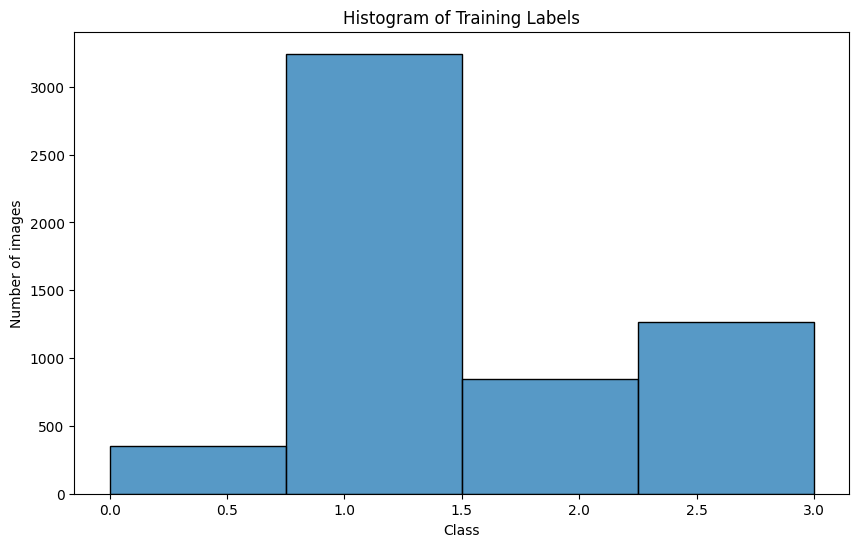

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(train_df["label"], bins=len(le.classes_), kde=False)
plt.title("Histogram of Training Labels")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.show()

Histogram of Validating

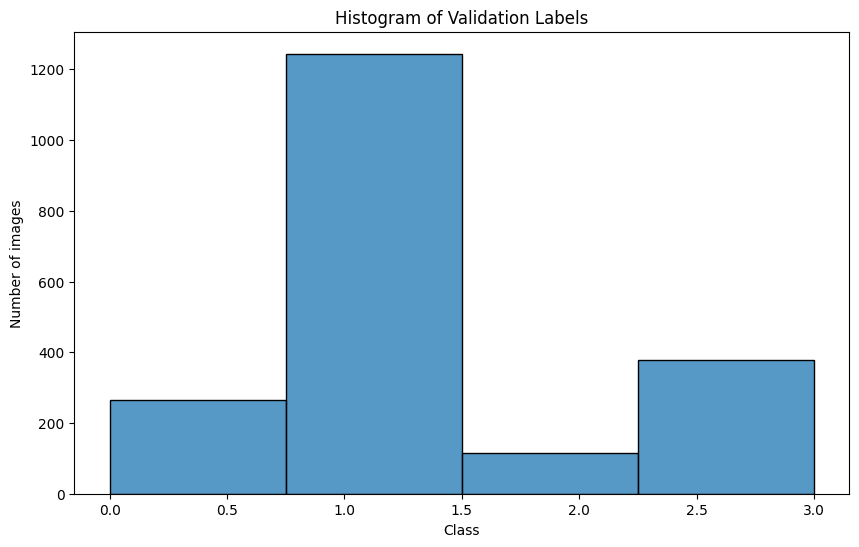

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(val_df["label"], bins=len(le.classes_), kde=False)
plt.title("Histogram of Validation Labels")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.show()

Bar chart Train & Valid

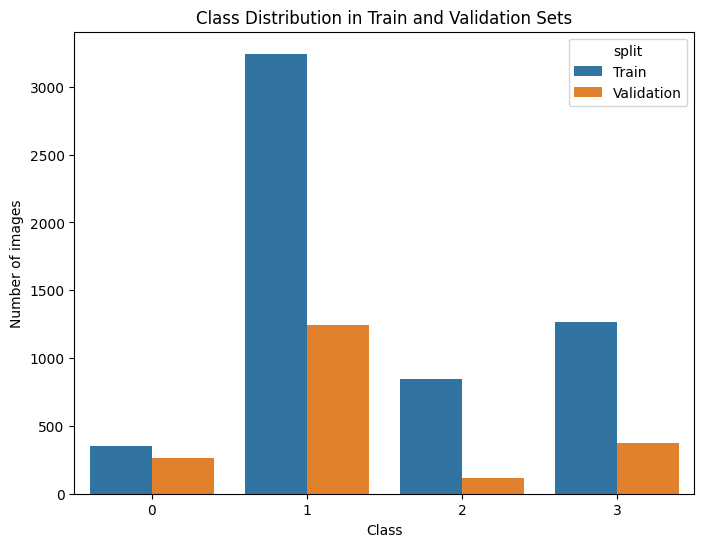

In [8]:
plt.figure(figsize=(8,6))
sns.countplot(data=df_all, x='label', hue='split')
plt.title("Class Distribution in Train and Validation Sets")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.show()

Heatmap

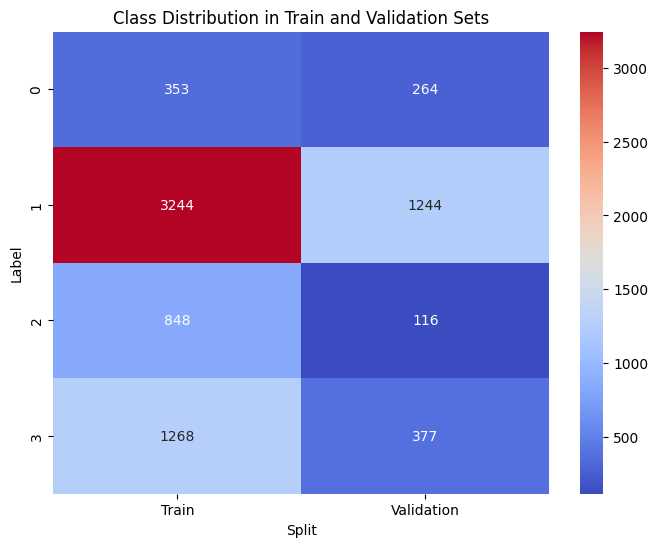

In [9]:
pivot = pd.pivot_table(df_all, values='file_path', index='label', columns='split', aggfunc='count', fill_value=0)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='coolwarm')
plt.title("Class Distribution in Train and Validation Sets")
plt.xlabel("Split")
plt.ylabel("Label")
plt.show()

As we have seen, our dataset is strongly overweighted, about 58% are B class (Ellipsoidal). So later we'll attempt to data augmentation, class weights, sampler

In [10]:
df_train_test = pd.read_csv(r"C:\Users\Lenovo\OneDrive - Hanoi University of Science and Technology\Desktop\HUST\train_data.csv")
print(df_train_test.shape)
print(df_train_test.head())

(5713, 2)
                                           file_path  label
0  C:\Users\Lenovo\OneDrive - Hanoi University of...      1
1  C:\Users\Lenovo\OneDrive - Hanoi University of...      3
2  C:\Users\Lenovo\OneDrive - Hanoi University of...      1
3  C:\Users\Lenovo\OneDrive - Hanoi University of...      1
4  C:\Users\Lenovo\OneDrive - Hanoi University of...      1


**Step2:** Train the ViT model

Now that we have basically done all the pre-split data visualization, let's begin with the train
- The technique we're goin to use is randomly choose 70% of the samples in train dataset
--> Apply 10-fold 
--> Train with a minimum of 50 times, to advoid randomness which may occurs during our training progress
==> Most important: Perform **Feture reduction** & **(Hyper)Parameter tuning**

Random 70% of samples + 10 fold cross-validation

**Matching dataset**

In [11]:
print(df.head(100))

            Train–test       Train–test.1       Validation
0   Pryntex-01-Ag-01_B  Botlek-01-Ag-10_B   762-27-Ag-10_B
1   Pryntex-01-Ag-02_D  Botlek-01-Ag-11_B  762-27-Ag-100_B
2   Pryntex-01-Ag-03_B  Botlek-01-Ag-12_D  762-27-Ag-101_B
3   Pryntex-01-Ag-04_B  Botlek-01-Ag-14_C  762-27-Ag-102_B
4   Pryntex-01-Ag-05_B  Botlek-01-Ag-15_B  762-27-Ag-103_B
..                 ...                ...              ...
95  Pryntex-03-Ag-04_B  Botlek-03-Ag-26_D  762-27-Ag-189_A
96  Pryntex-03-Ag-05_B  Botlek-03-Ag-27_D   762-27-Ag-19_B
97  Pryntex-03-Ag-06_B  Botlek-03-Ag-28_B  762-27-Ag-190_B
98  Pryntex-03-Ag-07_B  Botlek-03-Ag-29_B  762-27-Ag-191_A
99  Pryntex-03-Ag-08_B   Botlek-03-Ag-3_B  762-27-Ag-192_A

[100 rows x 3 columns]


**Datasplit from **matched**

In [12]:
from sklearn.model_selection import train_test_split

train_df_split, test_df_split = train_test_split(
    train_df,
    test_size=0.3,
    random_state=42,
    stratify=train_df["label"],
    shuffle=True
)


In [13]:
train_paths = train_df_split["file_path"].to_numpy()
train_labels = train_df_split["label"].to_numpy()

test_paths = test_df_split["file_path"].to_numpy()
test_labels = test_df_split["label"].to_numpy()

print(len(train_paths), len(train_labels))  # phải bằng nhau


3999 3999


Define dataset class

In [14]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class CBDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        # convert everything to list
        self.image_paths = list(image_paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


Data augmentation

In [15]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

**10-fold cross validation only on train_files**

In [16]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader

skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

for fold, (tr_idx, val_idx) in enumerate(skf.split(train_paths, train_labels)):
    print(f"\nFold {fold + 1}")

    X_train = train_paths[tr_idx]
    y_train = train_labels[tr_idx]

    X_val = train_paths[val_idx]
    y_val = train_labels[val_idx]

    train_dataset = CBDataset(
        image_paths=X_train,
        labels=y_train,
        transform=train_transform
    )

    val_dataset = CBDataset(
        image_paths=X_val,
        labels=y_val,
        transform=test_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print("Train samples:", len(train_dataset))
    print("Val samples:", len(val_dataset))

    # train_one_fold(model, train_loader, val_loader, fold)



Fold 1
Train samples: 3599
Val samples: 400

Fold 2
Train samples: 3599
Val samples: 400

Fold 3
Train samples: 3599
Val samples: 400

Fold 4
Train samples: 3599
Val samples: 400

Fold 5
Train samples: 3599
Val samples: 400

Fold 6
Train samples: 3599
Val samples: 400

Fold 7
Train samples: 3599
Val samples: 400

Fold 8
Train samples: 3599
Val samples: 400

Fold 9
Train samples: 3599
Val samples: 400

Fold 10
Train samples: 3600
Val samples: 399


DataLoader

In [17]:
from torch.utils.data import DataLoader

train_dataset = CBDataset(
    train_paths,
    train_labels,
    transform=train_transform   # AUGMENTATION
)

test_dataset = CBDataset(
    test_paths,
    test_labels,
    transform=test_transform    # NO AUGMENT
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,   
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,  
    pin_memory=False
)

**Train**

Here we're going to use ViT - L/16 - ImageNet. Load the pretrained weights using Pytorch

In [18]:
import torchvision.models as models
from torchvision.models import ViT_L_16_Weights

#Load the model with the best available weights (ImageNet fine-tuned)
weights = ViT_L_16_Weights.IMAGENET1K_V1
model = models.vit_l_16(weights=weights)

model.eval() #Set model to evaluation mode

#Use the appropriate transform for preprocessing the input images
preprocess = weights.transforms

Replace classification head

In [19]:
import torch

In [20]:
import torch
import torch.nn as nn
from torchvision.models import vit_l_16, ViT_L_16_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"

weights = ViT_L_16_Weights.IMAGENET1K_V1
model = vit_l_16(weights=weights)

num_classes = 4
model.heads.head = nn.Linear(
    model.heads.head.in_features,
    num_classes
)

model = model.to(device)

Freezer backbone

In [21]:
for param in model.parameters():
    param.requires_grad = False

for param in model.heads.parameters():
    param.requires_grad = True

In [22]:
model.train()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05
)

criterion = nn.CrossEntropyLoss()

In [23]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")


2.10.0+cpu
False
NO GPU


In [24]:
print(len(train_loader),len(val_loader))

125 13


In [25]:
print(model)

VisionTransformer(
  (conv_proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=4096, out_features=1024, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
       

**Training Loop**

In [26]:
from sklearn.metrics import accuracy_score
import numpy as np

for epoch in range(30)

    # TRAIN
    model.train()
    train_losses = []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    # VALIDATION 
    model.eval()
    val_losses = []
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_losses.append(loss.item())
            val_preds.extend(outputs.argmax(1).cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_targets, val_preds)

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss {np.mean(train_losses):.4f} | "
        f"Val loss {np.mean(val_losses):.4f} | "
        f"Val acc {val_acc:.4f}"
    )


SyntaxError: expected ':' (2629205848.py, line 4)

In [ ]:
inputs, labels = next(iter(test_loader))
inputs, labels = inputs.to(device), labels.to(device)
outputs = model(inputs)

print("Predicted classes", outputs.argmax(-1))
print("Actual classes", labels)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

In [ ]:
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()